In [ ]:
import pandas as pd
import numpy as np
import json
import re
import time
import os
import matplotlib.pyplot as plt
import seaborn as sns
import concurrent.futures # To setup multiple threads

from google.colab import userdata
from sklearn.metrics import mean_absolute_error
from google import genai
from google.genai import types
from tqdm.auto import tqdm

In [15]:
# ==========================================
# 1. THE GOLDEN DATASET
# ==========================================

golden_df = pd.read_csv("cyber_intel_requirements_with_explanations.csv")
golden_df.drop(0,axis=0,inplace=True)

# Mapping text ratings to integers for scoring
RATING_MAP = {"Poor": 1, "Good": 2, "Better": 3, "Best": 4}

golden_df["Specificity Rating"] = golden_df["Specificity Rating"].map(RATING_MAP)
golden_df["Decision Rating"] = golden_df["Decision Rating"].map(RATING_MAP)
golden_df["Feasibility Rating"] = golden_df["Feasibility Rating"].map(RATING_MAP)
golden_df

,Requirement,Specificity Rating,Specificity Explanation,Decision Rating,Decision Explanation,Feasibility Rating,Feasibility Explanation,Overall QIR Grade
1,How risky is our cloud environment?,1,Scope unclear; not a single question.,2,General risk posture but not decision-specific.,2,Can partially evaluate from assessments.,Poor
2,What are the top cyber risks to our environment?,1,"Broad, multi-dimensional.",1,No decision dependency.,3,Cataloging possible but unfocused.,Poor
3,Which threat actors target companies like us?,2,Narrowed to actor set but still broad.,2,Supports awareness—not a single decision.,3,Threat intel available from multiple sources.,Good
4,Are any of our privileged accounts showing ano...,2,Scoped to privileged accounts but comparative.,2,Supports monitoring—not one decision.,3,Logs and UEBA available.,Good
5,Are phishing attacks increasing in our sector ...,3,"Clear technique, sector, and timeframe.",2,Informs posture—not one decision.,3,Telemetry exists to answer.,Better
6,Is the new vulnerability in Library X likely t...,3,"Specific library, asset class, time window.",3,Supports remediation prioritization decisions.,3,Requires scanning and mapping but doable.,Better
7,Are malware loaders L1 or L2 being used by adv...,3,"Specific loaders, environment context.",3,Helps detection engineering decisions.,3,Threat intel exists.,Better
8,Is Threat Actor A deploying stolen OAuth token...,3,Actor + technique + region + timeframe.,3,Supports auth control changes.,3,Logs and intel available.,Better
9,Does Malware Variant M have capabilities to by...,3,Specific malware + capability + environment.,3,Informs EDR tuning.,2,Requires sandboxing.,Better
10,Are any of our GitHub repositories being clone...,3,Technique + asset + timeframe.,3,Supports investigation.,3,Logs available.,Better


In [ ]:
# ==========================================
# 2. PROMPT DEFINITIONS
# ==========================================

PROMPT_STRATEGY_A_COMBINED = """
You are an intelligence analysis evaluator with extensive experience aligning
corporate leadership requirements with cybersecurity capabilities. Your task is
to assess the quality of the provided cybersecurity intelligence requirement.
Evaluate it across the following three variables, using the 1–4 scale:

1 = Poor
2 = Good
3 = Better
4 = Best

Definitions:
- Specificity: Whether the requirement asks a single, clearly defined, narrowly
  scoped question with explicit actors/assets/timeframes.
- Decision-Centricity: Whether the requirement directly supports one specific
  decision with a clear decision point.
- Feasibility: Whether the requirement can realistically be answered using typical
  cybersecurity telemetry, intelligence sources, or analytic capabilities.

For the intelligence requirement provided, perform the following:
1. Provide a rating (1–4) for Specificity and an explanation.
2. Provide a rating (1–4) for Decision-Centricity and an explanation.
3. Provide a rating (1–4) for Feasibility and an explanation.
4. For any variable scoring less than 4, provide clear recommended actions to
    improve the requirement to a “Best” rating.

Respond only in JSON using this structure:

{
  "specificity_rating": number,
  "specificity_explanation": "text",
  "specificity_recommended_actions": "text or null",
  "decision_centricity_rating": number,
  "decision_centricity_explanation": "text",
  "decision_centricity_recommended_actions": "text or null",
  "feasibility_rating": number,
  "feasibility_explanation": "text",
  "feasibility_recommended_actions": "text or null",
}

Here is an example of what a quality rated intelligence requirement looks like:
{
  "Intelligence Requirement": "What cyber threats should we worry about this year?",
  "specificity_rating": 1,
  "specificity_explanation": "Very broad, undefined and multi-dimensional.",
  "decision_centricity_rating": 1,
  "decision_centricity_explanation": "No single decision tied to requirement.",
  "feasibility_rating": 2,
  "feasibility_explanation": "High-level trends answerable but unfocused.",
}

Now evaluate this intelligence requirement: <<<INSERT REQUIREMENT HERE>>>.
"""

In [ ]:
PROMPT_STRATEGY_B_SPECIFICITY = """
You are an intelligence analysis evaluator with extensive experience aligning
corporate leadership requirements with cybersecurity capabilities. Assess the
provided cybersecurity intelligence requirement ONLY on its Specificity.

Rating scale:
1 = Poor (broad, vague, compound, ambiguous)
2 = Good (narrower but missing clarity or tight parameters)
3 = Better (single question but lacks explicit actors/assets/timeframes)
4 = Best (a single, highly specific, measurable question with explicit scoping)

Provide:
- A specificity rating (1–4)
- An explanation
- Recommended actions (ONLY if the rating is less than 4) describing how to make the requirement fully specific.

Respond in JSON:

{
  "specificity_rating": number,
  "specificity_explanation": "text",
  "recommended_actions": "text or null"
}

Here is an example of what a quality rated intelligence requirement around specificity looks like:
{
  "Intelligence Requirement": "What cyber threats should we worry about this year?",
  "specificity_rating": 1,
  "specificity_explanation": "Very broad, undefined and multi-dimensional.",
}

Now evaluate this intelligence requirement: <<<INSERT REQUIREMENT HERE>>>.
"""

PROMPT_STRATEGY_B_DECISION = """
You are an intelligence analysis evaluator with extensive experience aligning
corporate leadership requirements with cybersecurity capabilities. Assess the
provided cybersecurity intelligence requirement ONLY on its Decision-Centricity.

Rating scale:
1 = Poor (no identifiable decision; general awareness)
2 = Good (loosely tied to a decision but not a single clear one)
3 = Better (supports a specific decision but missing clear timing, owner, or action)
4 = Best (clearly tied to one concrete decision such as block/allow, revoke/approve, patch/defer)

Provide:
- A decision-centricity rating (1–4)
- An explanation
- Recommended actions (ONLY if the rating is less than 4) describing how to clearly
tie the requirement to a single decision.

Respond in JSON:

{
  "decision_centricity_rating": number,
  "decision_centricity_explanation": "text",
  "recommended_actions": "text or null"
}

Here is an example of what a quality rated intelligence requirement around decision centricity looks like:
{
  "Intelligence Requirement": "What cyber threats should we worry about this year?",
  "decision_centricity_rating": 1,
  "decision_centricity_explanation": "No single decision tied to requirement.",
}

Now evaluate this intelligence requirement: <<<INSERT REQUIREMENT HERE>>>.
"""

PROMPT_STRATEGY_B_FEASIBILITY = """
You are an intelligence analysis evaluator with extensive experience aligning
corporate leadership requirements with cybersecurity capabilities. Assess the
provided cybersecurity intelligence requirement ONLY on its Feasibility.

Rating scale:
1 = Poor (cannot realistically be answered with existing capabilities)
2 = Good (partially answerable but with major gaps)
3 = Better (answerable with moderate effort; some constraints)
4 = Best (readily answerable using typical cybersecurity telemetry, logs, and intelligence sources)

Provide:
- A feasibility rating (1–4)
- An explanation
- Recommended actions (ONLY if the rating is less than 4) describing how to make the requirement realistically answerable.

Respond in JSON:

{
  "feasibility_rating": number,
  "feasibility_explanation": "text",
  "recommended_actions": "text or null"
}

Here is an example of what a quality rated intelligence requirement around feasibility looks like:
{
  "Intelligence Requirement": "What cyber threats should we worry about this year?",
  "feasibility_rating": 2,
  "feasibility_explanation": "High-level trends answerable but unfocused.",
}

Now evaluate this intelligence requirement: <<<INSERT REQUIREMENT HERE>>>.
"""

In [18]:
import getpass

# Prompt user for API key using getpass
gemini_api_key_input = getpass.getpass('Enter your GEMINI_API_KEY: ')

Enter your GEMINI_API_KEY: ··········


In [19]:
# NOTE: REQUIRES API KEY - this cell ends with a live test call (1 model call).

def _call_gemini_api(prompt_text, model_name="gemini-3.1-pro-preview", temperature=0.5, api_key=gemini_api_key_input):
    """
    Updated helper function using the new google.genai Client SDK.
    """
    try:
        # Use provided API key if available, otherwise try userdata.get()
        key_to_use = api_key if api_key else userdata.get('GEMINI_API_KEY')

        client = genai.Client(api_key=key_to_use)

        # New: Call generate_content via client.models
        response = client.models.generate_content(
            model=model_name,
            contents=prompt_text,
            config=types.GenerateContentConfig(
                temperature=temperature,
                response_mime_type="application/json"
            )
        )

        if response.text:
            return response.text
        else:
            # Handle cases where response.text might be empty but no error occurred
            print("Warning: API response text was empty.")
            return json.dumps({})

    except Exception as e:
        print(f"Error calling new Gemini API: {e}")
        return json.dumps({})

# Run a test of the llm call
_call_gemini_api('hi')

'{\n  "message": "Hello! How can I help you today?"\n}'

In [20]:
def parse_llm_response(response_text):
    """Cleaning function to handle Markdown backticks often returned by LLMs."""
    try:
        # Remove ```json and ``` if present
        clean_text = re.sub(r'```json\s*', '', response_text)
        clean_text = re.sub(r'```', '', clean_text)
        return json.loads(clean_text)
    except Exception as e:
        print(f"Error parsing JSON: {e}")
        return None

In [ ]:
# -------------------------------------------------------------------------
# 1. CONFIGURATION
# -------------------------------------------------------------------------
SIMULATION_COUNT = 5     # Number of full passes per configuration
MAX_WORKERS = 19          # Parallel concurrency limit
COOLDOWN_SECONDS = 60      # Pause between simulation passes to reset the per-minute quota

# Grid Search Parameters
model_name = "gemini-3.1-pro-preview"
TEMPERATURES = [0.0, 0.5, 1.0]
STRATEGIES = ["PROMPT_STRATEGY_A_COMBINED", "Chained_Prompts" ]

In [22]:
# -------------------------------------------------------------------------
# 2. WORKER: Process Single Requirement (One Row)
# -------------------------------------------------------------------------
def process_single_case(strategy_name, row, temperature, model_name=model_name):
    """
    Runs ONE test case. Returns the absolute error for this specific item.
    """
    req_text = row["Requirement"]

    # Defaults
    pred_spec, pred_dec, pred_feas = np.nan, np.nan, np.nan
    spec_exp, dec_exp, feas_exp = "", "", ""

    try:
        # --- STRATEGY A ---
        if strategy_name == "PROMPT_STRATEGY_A_COMBINED":
            final_prompt = PROMPT_STRATEGY_A_COMBINED.replace("<<<INSERT REQUIREMENT HERE>>>", req_text)
            raw_resp = _call_gemini_api(prompt_text=final_prompt, model_name=model_name, temperature=temperature)
            data = parse_llm_response(raw_resp) or {}

            pred_spec = data.get("specificity_rating", np.nan)
            pred_dec = data.get("decision_centricity_rating", np.nan)
            pred_feas = data.get("feasibility_rating", np.nan)

            spec_exp = data.get("specificity_explanation", "")
            dec_exp = data.get("decision_centricity_explanation", "")
            feas_exp = data.get("feasibility_explanation", "")

        # --- STRATEGY B: CHAINED ---
        elif strategy_name == "Chained_Prompts":
            # 1. Specificity
            p_spec = PROMPT_STRATEGY_B_SPECIFICITY.replace("<<<INSERT REQUIREMENT HERE>>>", req_text)
            r_spec = _call_gemini_api(prompt_text=p_spec, model_name=model_name, temperature=temperature)
            time.sleep(COOLDOWN_SECONDS)
            d_spec = parse_llm_response(r_spec) or {}
            pred_spec = d_spec.get("specificity_rating", np.nan)
            spec_exp = d_spec.get("explanation", "")
            spec_rec = d_spec.get("recommended_actions", "")

            # 2. Decision
            p_dec = PROMPT_STRATEGY_B_DECISION.replace("<<<INSERT REQUIREMENT HERE>>>", req_text)
            r_dec = _call_gemini_api(prompt_text=p_dec, model_name=model_name, temperature=temperature)
            time.sleep(COOLDOWN_SECONDS)
            d_dec = parse_llm_response(r_dec) or {}
            pred_dec = d_dec.get("decision_centricity_rating", np.nan)
            dec_exp = d_dec.get("explanation", "")
            dec_rec = d_dec.get("recommended_actions", "")

            # 3. Feasibility
            p_fea = PROMPT_STRATEGY_B_FEASIBILITY.replace("<<<INSERT REQUIREMENT HERE>>>", req_text)
            r_fea = _call_gemini_api(prompt_text=p_fea, model_name=model_name, temperature=temperature)
            time.sleep(COOLDOWN_SECONDS)
            d_fea = parse_llm_response(r_fea) or {}
            pred_feas = d_fea.get("feasibility_rating", np.nan)
            feas_exp = d_fea.get("explanation", "")
            feas_rec = d_fea.get("recommended_actions", "")

        # --- CALCULATE ERROR FOR THIS ITEM ---
        y_pred = [pred_spec, pred_dec, pred_feas]
        y_true = [row["Specificity Rating"], row["Decision Rating"], row["Feasibility Rating"]]

        cleaned_true = [t for t, p in zip(y_true, y_pred) if not pd.isna(p)]
        cleaned_pred = [p for p in y_pred if not pd.isna(p)]

        item_mae = np.nan
        if len(cleaned_true) > 0:
            item_mae = mean_absolute_error(cleaned_true, cleaned_pred)

        return {
            "mae": item_mae,
            "details": {
                "Requirement": req_text,
                "Model": model_name,
                "Temperature": temperature,
                "Strategy": strategy_name,
                "MAE_Item": item_mae,
                "True Spec": row["Specificity Rating"], "Pred Spec": pred_spec, "Spec Exp": spec_exp,
                "True Dec": row["Decision Rating"], "Pred Dec": pred_dec, "Dec Exp": dec_exp,
                "True Feas": row["Feasibility Rating"], "Pred Feas": pred_feas, "Feas Exp": feas_exp,
            }
        }

    except Exception:
        return {"mae": np.nan, "details": None}

In [23]:
# -------------------------------------------------------------------------
# 3. EXPERIMENT RUNNER: One Full Pass
# -------------------------------------------------------------------------
def run_burst_experiment_pass(strategy_name, temperature):
    """
    Runs all 19 items in parallel, calculates MAE, then SLEEPS.
    """
    item_maes = []
    detailed_logs = []

    # 1. BURST: Fire all requests at once
    # We use a ThreadPool to send them simultaneously
    with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        future_to_case = {
            executor.submit(process_single_case, strategy_name, row, temperature): i
            for i, row in tqdm(golden_df.iterrows())
        }

        # Wait for all to complete
        for future in concurrent.futures.as_completed(future_to_case):
            try:
                res = future.result(timeout=30)
                if res and not np.isnan(res["mae"]):
                    item_maes.append(res["mae"])
                    detailed_logs.append(res["details"])
            except Exception as e:
              print("Error:", e)

    # 2. CALCULATE RESULTS
    mae = np.mean(item_maes) if item_maes else np.nan

    return mae, detailed_logs

In [41]:
def run_burst_simulation_loop():
    print(f"--- Starting Burst Strategy (Batch Size: {len(golden_df)}) ---")
    print(f"--- Cooldown: {COOLDOWN_SECONDS}s between runs ---")

    start_time = time.time()
    summary_stats = []
    raw_simulation_logs = []
    best_global_mae = float('inf')
    best_logs = []

    for strat in tqdm(STRATEGIES, desc="Strategies"):
        for temp in tqdm(TEMPERATURES, desc="Temps", leave=False):
            config_label = f"{strat}\n(T={temp})"
            run_maes = []

            for i in tqdm(range(SIMULATION_COUNT), desc="Sims", leave=False):

                # --- EXECUTE BATCH ---
                exp_mae, logs = run_burst_experiment_pass(strat, temp)

                if not np.isnan(exp_mae):
                    run_maes.append(exp_mae)
                    raw_simulation_logs.append({
                        "Configuration": config_label,
                        "MAE": round(exp_mae, 4)
                    })
                    if exp_mae < best_global_mae:
                        best_global_mae = exp_mae
                        best_logs = logs

                # --- THE SAFETY SLEEP ---
                # We only need to sleep if there are more runs coming.
                # Note: this guard is always true, so the cooldown also runs after the final pass.
                if i < SIMULATION_COUNT:
                    time.sleep(COOLDOWN_SECONDS)

            if run_maes:
                summary_stats.append({
                    "Configuration": config_label,
                    "Mean MAE": round(np.mean(run_maes), 4),
                    "Std Dev": round(np.std(run_maes, ddof=1), 4)
                })

    print(f"Total Time: {(time.time() - start_time)/60:.2f} minutes")
    return pd.DataFrame(summary_stats), pd.DataFrame(raw_simulation_logs), pd.DataFrame(best_logs)

In [12]:
# -------------------------------------------------------------------------
# 5. VISUALIZATION FUNCTION
# -------------------------------------------------------------------------
def plot_simulation_results(df_raw):
    """
    Generates a Box Plot overlaid with a Scatter Plot (Strip Plot).
    """
    plt.figure(figsize=(12, 10))

    # 1. Box Plot (Shows the distribution, quartiles, and whiskers)
    sns.boxplot(
        data=df_raw,
        x="Configuration",
        y="MAE",
        showfliers=False, # Hide outliers in boxplot, we see them in scatter
        color="white",
        linewidth=1.5,
        width=0.5
    )

    # 2. Scatter Plot (Shows individual simulation runs)
    sns.stripplot(
        data=df_raw,
        x="Configuration",
        y="MAE",
        color="red",
        alpha=0.6,    # Transparency
        jitter=0.1,   # Spread dots horizontally so they don't overlap
        size=8
    )

    plt.title(f"Simulation Variance: MAE Distribution across {SIMULATION_COUNT} Runs", fontsize=14)
    plt.ylabel("Mean Absolute Error (Lower is Better)", fontsize=12)
    plt.xlabel("Configuration", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right')

    # Show plot
    plt.tight_layout()
    plt.savefig('simulation_results.png',dpi=300)
    plt.show()

In [42]:
# NOTE: REQUIRES API KEY - full grid search: ~1,140 model calls, ~75-85 minutes
# (runtime dominated by built-in cooldowns). The shipped df_raw_runs.csv already
# holds the recorded results if you want to skip the spend.

# 1. Run the Simulation
df_stats, df_raw_runs, df_winner_logs = run_burst_simulation_loop()

df_raw_runs.to_csv('df_raw_runs.csv', index=False)

--- Starting Burst Strategy (Batch Size: 19) ---
--- Cooldown: 61s between runs ---


Strategies:   0%|          | 0/1 [00:00<?, ?it/s]

Temps:   0%|          | 0/1 [00:00<?, ?it/s]

Sims:   0%|          | 0/2 [00:00<?, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

Total Time: 3.72 minutes


In [ ]:
# Load grid results for the stats table and plot below.
# Keyless readers: this reads the recorded runs shipped in df_raw_runs.csv —
# no API key or paid simulation needed. After a fresh grid run above, it
# simply re-reads the CSV that run just wrote.
import pandas as pd
df_raw_runs = pd.read_csv("df_raw_runs.csv")
print(f"Loaded {len(df_raw_runs)} recorded runs from df_raw_runs.csv")

,mean,std
Configuration,,
Chained_Prompts\n(T=0.0),0.52630,0.000000
Chained_Prompts\n(T=0.5),0.47720,0.026024
Chained_Prompts\n(T=1.0),0.47896,0.040006
PROMPT_STRATEGY_A_COMBINED\n(T=0.0),0.38600,0.000000
PROMPT_STRATEGY_A_COMBINED\n(T=0.5),0.43510,0.026024
PROMPT_STRATEGY_A_COMBINED\n(T=1.0),0.35750,0.055467


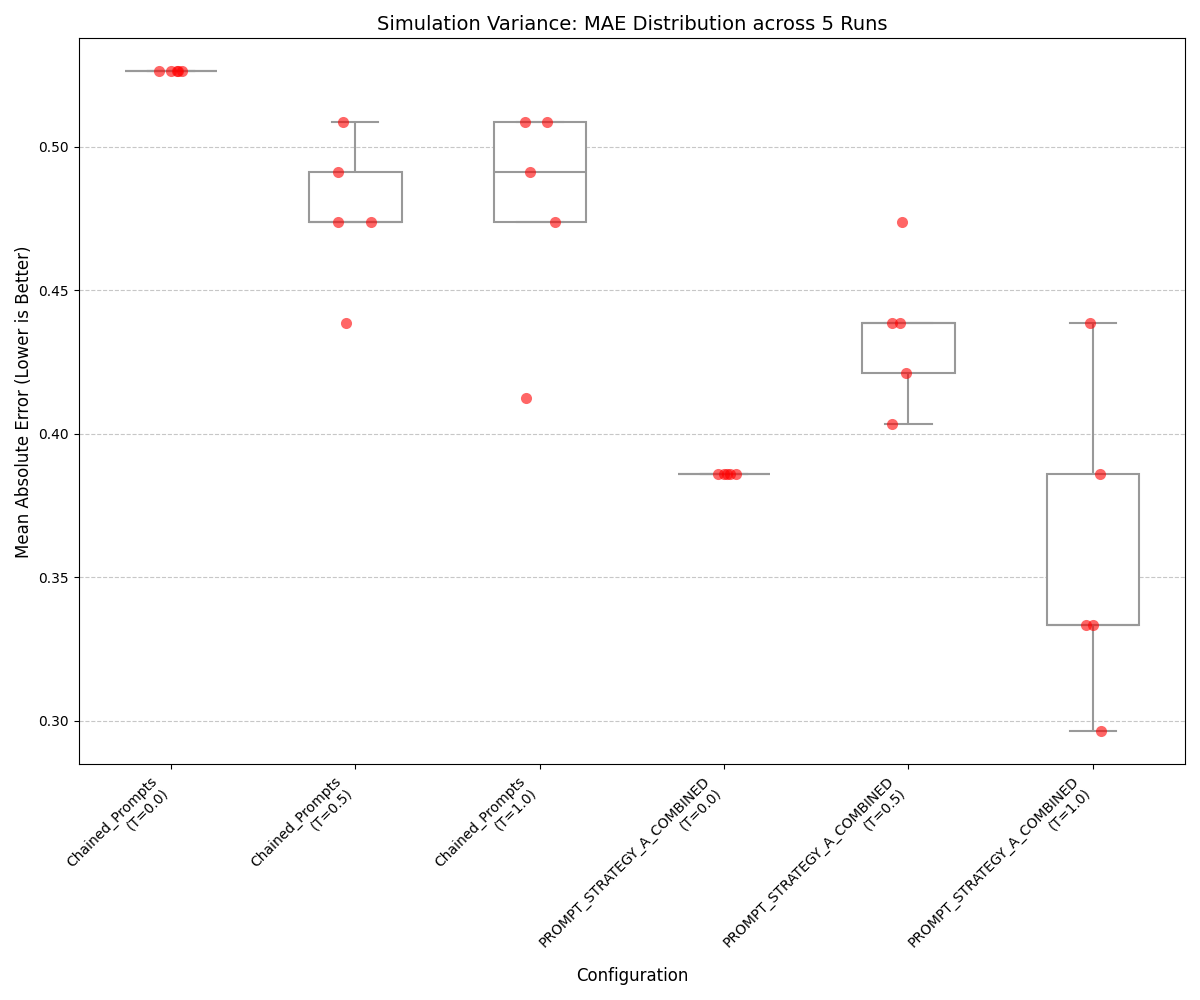

In [39]:
# 2. Display the Stats Table
# Ensure MAE is numeric
df_raw_runs['MAE'] = pd.to_numeric(df_raw_runs['MAE'])

# Compute Mean and Standard Deviation
summary_stats = df_raw_runs.groupby('Configuration')['MAE'].agg(['mean', 'std'])
display(summary_stats)

# 3. Plot Results
if not df_raw_runs.empty:
  plot_simulation_results(df_raw_runs)
else:
    print("No data to plot.")